# Знакомство с Gym (продолжение)

В предыдущем уроке мы рассмотрели пример игры `Frozen Lake` и попробовали создать стратегию для игры а неё вручную. Перед тем, как переходить к обучению RL агентов, продолжим знакомство с Gym и рассмотрим пример более сложной игры -- `Pong` (одна из игра Atari). Особенность данной игры, во-первых, в более сложном состоянии, а во-вторых, в более сложном способе визуализации такого состояния. Эта игра будет содержать визуальное состояние, а игровой процесс будет содержать анимацию, поэтому для рендеринга игрового процесса Gym захочет создать дополнительное окно. Но так как мы работаем в Colab и дополнительных окон создать нельзя, нам придётся записывать игровой процесс на видео и потом воспроизводить его.

### Загрузка библиотек

Кроме Gym нам понадобятся `matplotlib` и `gym.wrappers.Monitor` для визуализации состояния игры.

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np

In [7]:
# 1. Сначала установите базовый пакет с Atari
!pip install gymnasium[atari]

# 2. Затем установите ROM-диски (с принятием лицензии)
!pip install gymnasium[accept-rom-license]
# Для Atari (Pong и другие)
!pip install "gymnasium[atari]"

# Для Box2D (LunarLander и др.)
!pip install "gymnasium[box2d]"

# Для всех сред сразу
!pip install "gymnasium[all]"

### Создание игровой среды

Создаём среду игры `Pong` и смотрим на пространства действий и состояний.

Состояние теперь это целая RGB картинка -- то, что игрок видит на экране (Размерности 210 на 160).

Кроме того, есть 6 действий. По сути, это все достпуные действия на реальной консоли Atari. Просто в случае игры Pong лишь часть этих действий будут к чему-то приводить (в Pong нам просто нужно будет двигать нашу ракетку в одну или в другую сторону, то есть лишь два действия будут реально рабочими).


In [4]:
import gymnasium as gym
import ale_py

# Принудительно регистрируем ALE среды
gym.register_envs(ale_py)

env = gym.make('ALE/Pong-v5', render_mode="human")

STATE_SHAPE = env.observation_space.shape
NUM_ACTIONS = env.action_space.n
ACTION_MEANING = env.unwrapped.get_action_meanings()

print('States shape: {}'.format(STATE_SHAPE))
print('Actions: {}'.format(NUM_ACTIONS))
print('Actions: {}'.format(ACTION_MEANING))
env.close()

States shape: (210, 160, 3)
Actions: 6
Actions: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


### Основные функции Gym

Приведём среду в исходное состояние, получим это состояние (`s`) и визуализируем его (это просто изображение)

None


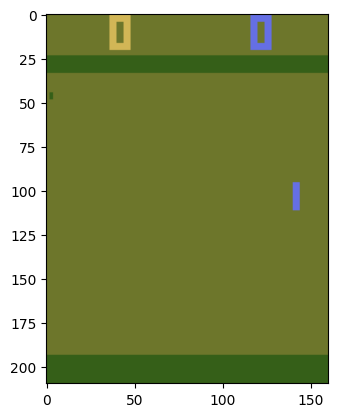

In [6]:
s, info = env.reset()
print(env.render())
_=plt.imshow(s)

Действия -- это по-прежнему просто числа (индекс действия)

In [7]:
a = env.action_space.sample()
print(a)

3


Произведем один шаг игры и получим следующее состояние. В первые несколько шагов реальная игра еще не началась и наш противник еще не появился на поле.

Reward:  0.0
Done?  False False


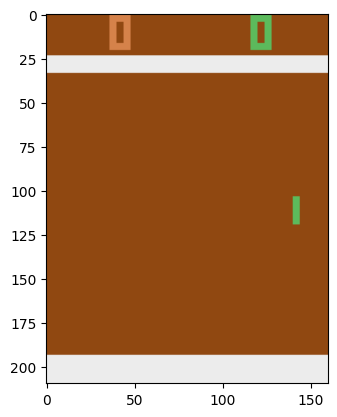

In [8]:
s1, r, terminated, truncated, _ = env.step(a)
print('Reward: ', r)
print('Done? ', terminated, truncated)
_=plt.imshow(s1)

### Визуализация игрового процесса

Стандартная визуализация игрового процесса через `env.render()` в Colab работать не будет, так как Gym будет пытаться создать отдельное окно, где он будет рендерить игровую симуляцию (в движении).

In [ ]:
# env.render() # не работает в Colab

Один из способов обойти эту проблему -- записать симуляцию на видео (без открытия дополнительных окон) и потом воспроизвести это видео. Можно расценивать это как хак.

Для этого нам понадобится установить некоторые дополнительные пакеты и запустить виртуальный дисплей.

In [1]:
#Современная настройка виртуального дисплея
# Установка необходимых пакетов
!apt-get update
!apt-get install -y xvfb ffmpeg x11-utils
!pip install pyvirtualdisplay pillow

from pyvirtualdisplay import Display
from IPython import display as ipythondisplay
from PIL import Image
import numpy as np
import time

# Запуск виртуального дисплея
display = Display(visible=0, size=(1400, 900))
display.start()

# Теперь можно использовать render_mode="human"
import gymnasium as gym
import ale_py

gym.register_envs(ale_py)
env = gym.make('ALE/Pong-v5', render_mode='human')

observation, info = env.reset()

# Функция для захвата и отображения кадров
def show_frame():
    # В Colab render_mode="human" не показывает окно,
    # поэтому захватываем rgb_array и отображаем через PIL
    frame = env.render()
    if frame is not None:
        img = Image.fromarray(frame)
        ipythondisplay.display(img)
        ipythondisplay.clear_output(wait=True)
# Запуск эпизода с отображением кадров
for i in range(100):
    action = env.action_space.sample()
    observation, reward, terminated, truncated, info = env.step(action)
    show_frame()
    time.sleep(0.05)  # небольшая задержка для визуализации

    if terminated or truncated:
        observation, info = env.reset()

env.close()

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:10 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

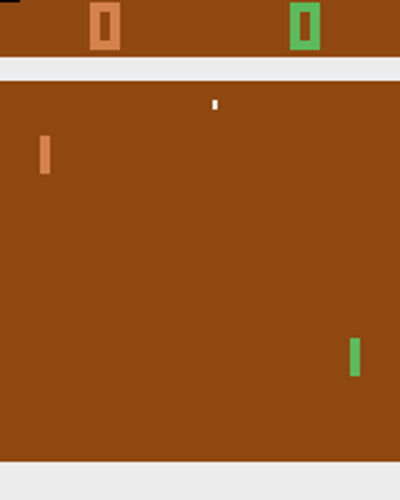

Обработано кадров: 46
Сохранен кадр 46 -> pong_frames/frame_0046.png
Сохранен кадр 47 -> pong_frames/frame_0047.png
Сохранен кадр 48 -> pong_frames/frame_0048.png
Сохранен кадр 49 -> pong_frames/frame_0049.png

=== ЗАПИСЬ ЗАВЕРШЕНА ===

=== СОХРАНЕННЫЕ ФАЙЛЫ ===
Всего сохранено кадров: 50
Файлы в папке (50):
  - frame_0000.png
  - frame_0001.png
  - frame_0002.png
  - frame_0003.png
  - frame_0004.png
  - frame_0005.png
  - frame_0006.png
  - frame_0007.png
  - frame_0008.png
  - frame_0009.png
  ... и еще 40


In [7]:
# Модифицированная версия с сохранением
from pyvirtualdisplay import Display
from IPython.display import Video, display as ipy_display  # переименовываем
from PIL import Image
import gymnasium as gym
import ale_py
import time
import os
import numpy as np

# Создаем папку для сохранения кадров
os.makedirs('pong_frames', exist_ok=True)
print(f"Папка создана: {os.path.abspath('pong_frames')}")

# Запуск виртуального дисплея
virtual_display = Display(visible=0, size=(1400, 900))  # называем virtual_display
virtual_display.start()

print("Виртуальный дисплей запущен")

# Создание среды
gym.register_envs(ale_py)
env = gym.make('ALE/Pong-v5', render_mode='rgb_array')

observation, info = env.reset()
frame_count = 0

def save_frame(frame_number):
    global frame_count

    # ПОЛУЧАЕМ КАДР ЧЕРЕЗ observation (более надежный способ)
    # Текущий кадр уже есть в observation
    frame = observation

    if frame is not None and isinstance(frame, np.ndarray):
        # Конвертируем в изображение
        img = Image.fromarray(frame)

        # СОХРАНЯЕМ В ФАЙЛ
        filename = f'pong_frames/frame_{frame_number:04d}.png'
        img.save(filename)
        print(f"Сохранен кадр {frame_number} -> {filename}")

        # Показываем в Colab (каждый 5-й кадр, чтобы не спамить)
        if frame_number % 5 == 0:
            ipythondisplay.clear_output(wait=True)
            ipythondisplay.display(img.resize((400, 500)))
            print(f"Обработано кадров: {frame_number + 1}")

        frame_count += 1
        return True
    else:
        print(f"Ошибка: кадр {frame_number} не получен")
        return False

print("\n=== НАЧАЛО ЗАПИСИ ===")
for i in range(50):  # 50 кадров
    # Выбираем действие
    action = env.action_space.sample()

    # Делаем шаг и получаем новый observation
    observation, reward, terminated, truncated, info = env.step(action)

    # Сохраняем кадр
    save_frame(i)

    # Небольшая задержка
    time.sleep(0.05)

    if terminated or truncated:
        print(f"\n=== ЭПИЗОД ЗАКОНЧЕН на шаге {i} ===")
        observation, info = env.reset()

env.close()
print("\n=== ЗАПИСЬ ЗАВЕРШЕНА ===")

# Показываем, что сохранилось
print("\n=== СОХРАНЕННЫЕ ФАЙЛЫ ===")
print(f"Всего сохранено кадров: {frame_count}")

if frame_count > 0:
    files = sorted(os.listdir('pong_frames'))
    print(f"Файлы в папке ({len(files)}):")
    for f in files[:10]:  # покажем первые 10
        print(f"  - {f}")

    if len(files) > 10:
        print(f"  ... и еще {len(files) - 10}")
else:
    print("ПРЕДУПРЕЖДЕНИЕ: Кадры не сохранились!")

In [5]:
# Монтируем Google Диск
from google.colab import drive
drive.mount('/content/drive')

# Создаем папку на Google Диске для видео
import os
video_folder = '/content/drive/MyDrive/ColabNotebooks/gym_videos'
os.makedirs(video_folder, exist_ok=True)
print(f"Видео будут сохраняться в: {video_folder}")

Mounted at /content/drive
Видео будут сохраняться в: /content/drive/MyDrive/ColabNotebooks/gym_videos


In [8]:
from PIL import Image
import numpy as np
import imageio.v2 as imageio  # Используем v2 для устранения warning
import os
from IPython.display import Video, HTML
from IPython import display as ipythondisplay
import base64
import io
import glob

# Создаем видео из сохраненных кадров
frames = []
frame_files = sorted(os.listdir('pong_frames'))

for frame_file in frame_files:
    if frame_file.endswith('.png'):
        img_path = os.path.join('pong_frames', frame_file)
        frames.append(imageio.imread(img_path))

# Сохраняем как видео
if frames:
# Путь для сохранения на Google Диске
    video_path = '/content/drive/MyDrive/ColabNotebooks/gym_videos/pong_gameplay.mp4'

    # Сохраняем видео
    imageio.mimsave(video_path, frames, fps=10)
    print(f"Видео сохранено на Google Диск: {video_path}")
    print(f"Размер: {os.path.getsize(video_path) / 1024:.1f} KB")
    print(f"Кадров: {len(frames)}")

    # Также сохраняем локальную копию для быстрого доступа
    imageio.mimsave('pong_gameplay.mp4', frames, fps=10)
    print(f"Локальная копия: pong_gameplay.mp4")

    # Показываем видео в Colab
    print("\nВоспроизведение видео:")
    ipy_display(Video(video_path, embed=True, width=600))
else:
    print("Нет кадров для создания видео")

Видео сохранено на Google Диск: /content/drive/MyDrive/ColabNotebooks/gym_videos/pong_gameplay.mp4
Размер: 5.3 KB
Кадров: 50
Локальная копия: pong_gameplay.mp4

Воспроизведение видео:


Для проигрывания видео, можно просто скачать его на свой компьютер и воспросизвести там. Но мы дополниельно создадим функцию для встраивания видеоплеера прямо в Colab.

Данная функция `show_video()` ищет видео в папке `./video/` и вставляет его данные прямо в HTML данного Colab ноутбука. Так как видео целиком встраивается в веб-страницу, следует быть аккуратными с очень большими видео файлами.

In [13]:
def show_video(video_path=None, folder=None):
    """
    Универсальная функция для просмотра видео в Colab

    Параметры:
    - video_path: конкретный путь к видео файлу
    - folder: папка для поиска видео (покажет первое найденное)
    """
    import glob
    import io
    import base64
    from IPython.display import HTML
    from IPython import display as ipythondisplay
    import os

    # Определяем, какое видео показывать
    if video_path and os.path.exists(video_path):
        mp4list = [video_path]
    elif folder:
        mp4list = glob.glob(os.path.join(folder, '*.mp4'))
    else:
        # По умолчанию ищем в стандартных папках
        mp4list = []
        for search_folder in ['./', './video', './pong_video', './pong_frames']:
            mp4list.extend(glob.glob(os.path.join(search_folder, '*.mp4')))

        # Ищем на Google Диске
        drive_folder = '/content/drive/MyDrive/ColabNotebooks/gym_videos'
        if os.path.exists(drive_folder):
            mp4list.extend(glob.glob(os.path.join(drive_folder, '*.mp4')))

    if len(mp4list) > 0:
        # Берем первое видео или самое новое
        mp4 = sorted(mp4list, key=os.path.getmtime)[-1]
        print(f"Показываем видео: {mp4}")
        print(f"   Размер: {os.path.getsize(mp4) / 1024:.1f} KB")
        print(f"   Создано: {time.ctime(os.path.getmtime(mp4))}")

        # Способ 1: через Video (проще)
        try:
            from IPython.display import Video
            return Video(mp4, embed=True, width=600)
        except:
            pass

        # Способ 2: через base64 (надежнее)
        video = io.open(mp4, 'r+b').read()
        encoded = base64.b64encode(video)
        ipythondisplay.display(HTML(data='''<video alt="test" autoplay
            loop controls style="height: 400px;">
            <source src="data:video/mp4;base64,{0}" type="video/mp4" />
            </video>'''.format(encoded.decode('ascii'))))
    else:
        print("Видео не найдено!")
        print("   Искали в:")
        if folder:
            print(f"   - {folder}")
        print("   - ./video/*.mp4")
        print("   - ./pong_video/*.mp4")
        print("   - /content/drive/MyDrive/ColabNotebooks/gym_videos/*.mp4")

Для того, чтобы перенаправить визуализацию нашей симуляции в видео файл, создадим объект `env_sim` клсса `Monitor` и будем использовать его вместо `env`

Для примера сделаем запись симуляции с одним шагом.

* Переходим в начальное состояние с помощью `reset()`. В этот момент Монитор сбрасывает внутреннее состояние, начинает запись видео и захватывает первый кадр (соответствующей первому, текущему состоянию).
* Делаем шаг симуляции (функция `step` с действием `a=0`). В этот момент Монитор посылает реальной среде `env` указание "сделать шаг" и захватывает очередной кадр (соответствующий новому состоянию).
* Заканчиваем симуляцию с помощью `env_sim.close()`. В этот момент Монитор записывает все собранные кадры на диск в видео файл (в папке `./video`)

In [12]:
from gymnasium.wrappers import RecordVideo
env_sim = RecordVideo(
    env,
    video_folder='./video',
    episode_trigger=lambda episode_id: True,  # записывать все эпизоды
    name_prefix='rl-video'
)

# Сброс и один шаг
s, info = env_sim.reset()  # в Gymnasium reset возвращает (obs, info)
s, r, terminated, truncated, info = env_sim.step(0)  # 5 значений!
done = terminated or truncated

env_sim.close()  # видео сохраняется здесь

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Воспроизведем симулацию с помощью функции `show_video()`. Это видео состоит всего из двух кадров (первых двух состояний, в которых мы побывали). Первое состояние имеет неправильный цвет (особенность игры), поэтому видео получилось мерцающим.

In [13]:
show_video()

Показываем видео: ./video/rl-video-episode-0.mp4
   Размер: 2.1 KB
   Создано: Wed Feb 25 13:48:03 2026


### Запуск симуляции

Теперь давате запустим полноценную симуляцию. Этот приактически такой же, как было в случае с Frozen Lake (спасибо Gym за удобный унифицированный интерфейс). В качестве стратегии будем как раньше использовать выбор случайного действия.

In [15]:
from gymnasium.wrappers import RecordVideo
import gymnasium as gym
import ale_py

# Регистрируем Atari
gym.register_envs(ale_py)

# Создаем среду (ВАЖНО: render_mode='rgb_array')
env = gym.make('ALE/Pong-v5', render_mode='rgb_array')

# Оборачиваем в RecordVideo (аналог Monitor)
env_sim = RecordVideo(
    env,
    video_folder='./video',  # папка для видео
    episode_trigger=lambda episode_id: True,  # записывать все эпизоды
    name_prefix='pong_recording'
)

# Сброс среды - В Гимназиуме reset() возвращает (observation, info)
s, info = env_sim.reset()
totalReward = 0

for step in range(1000):
    # В Гимназиуме render() не всегда нужен - кадры захватываются автоматически
    # env_sim.render()  # МОЖНО УБРАТЬ, RecordVideo сам захватывает кадры

    # Случайное действие
    a = env_sim.action_space.sample()

    # Шаг среды - В Гимназиуме step() возвращает 5 значений!
    s, r, terminated, truncated, info = env_sim.step(a)

    # Объединяем флаги окончания
    done = terminated or truncated

    totalReward += r

    # Выводим ненулевые награды
    if r != 0:
        print(f'New reward = {r} (шаг {step})')

    # Проверка окончания эпизода
    if done:
        print(f'Эпизод закончен на шаге {step}')
        break

# Важно! Закрываем среду для сохранения видео
env_sim.close()

print(f'Total reward = {totalReward}')

# Проверяем, что видео сохранилось
import glob
videos = sorted(glob.glob('./video/*.mp4'), key=os.path.getmtime)
if videos:
    latest_video = videos[-1]
    print(f"\nПоследнее видео: {latest_video}")
    # ИСПРАВЛЕНИЕ: используем ipy_display вместо display
    ipy_display(Video(latest_video, embed=True, width=600))

New reward = -1.0 (шаг 63)
New reward = -1.0 (шаг 98)
New reward = -1.0 (шаг 133)
New reward = -1.0 (шаг 168)
New reward = -1.0 (шаг 203)
New reward = -1.0 (шаг 238)
New reward = -1.0 (шаг 273)
New reward = -1.0 (шаг 308)
New reward = -1.0 (шаг 343)
New reward = -1.0 (шаг 378)
New reward = -1.0 (шаг 413)
New reward = -1.0 (шаг 448)
New reward = -1.0 (шаг 483)
New reward = -1.0 (шаг 518)
New reward = -1.0 (шаг 553)
New reward = -1.0 (шаг 588)
New reward = -1.0 (шаг 623)
New reward = -1.0 (шаг 658)
New reward = -1.0 (шаг 753)
New reward = -1.0 (шаг 788)
New reward = -1.0 (шаг 851)
Эпизод закончен на шаге 851
Total reward = -21.0

Последнее видео: ./video/pong_recording-episode-0.mp4


Воспроизведём симуляцию

In [16]:
show_video()

Показываем видео: ./video/pong_recording-episode-0.mp4
   Размер: 46.5 KB
   Создано: Wed Feb 25 13:51:39 2026


**[Задание 1]** Протестируйте другие игры из Gym: `Assault-v0` и `CarRacing-v0`. А именно, создайте соответствующую среду, монитор для записи видео и цикл симуляции со случайными действиями. В конце должен получиться видео файл с анимацией вашей симуляции (встроенный в Colab).

https://gym.openai.com/envs

Для некоторых симуляций может потребоваться установить расширение для gym:

`!pip install 'gym[atari]'`

`!pip install 'gym[box2d]'`

In [17]:
# 1. Сначала установите базовый пакет с Atari
!pip install gymnasium[atari]

# 2. Затем установите ROM-диски (с принятием лицензии)
!pip install gymnasium[accept-rom-license]
# Для Atari (Pong и другие)
!pip install "gymnasium[atari]"



In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
import numpy as np

In [2]:
import gymnasium as gym
import ale_py

# Принудительно регистрируем ALE среды
gym.register_envs(ale_py)

env = gym.make('ALE/Assault-v5', render_mode="rgb_array")

STATE_SHAPE = env.observation_space.shape
NUM_ACTIONS = env.action_space.n
ACTION_MEANING = env.unwrapped.get_action_meanings()

print('States shape: {}'.format(STATE_SHAPE))
print('Actions: {}'.format(NUM_ACTIONS))
print('Actions: {}'.format(ACTION_MEANING))
env.close()

States shape: (210, 160, 3)
Actions: 7
Actions: ['NOOP', 'FIRE', 'UP', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


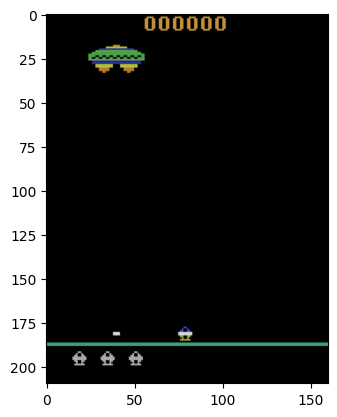

In [5]:
s, info = env.reset()
print(env.render())
_=plt.imshow(s)

In [10]:
#произведем шаг игры
a = env.action_space.sample()
print(a)

4


Reward:  0.0
Done?  False False


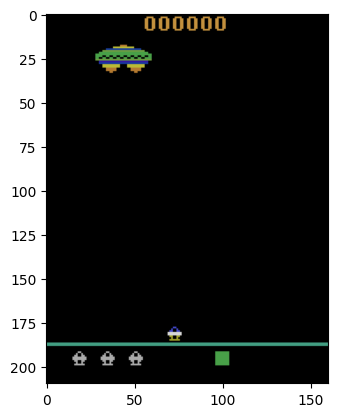

In [11]:
#возпроизведем это одно действие
s1, r, terminated, truncated, _ = env.step(a)
print('Reward: ', r)
print('Done? ', terminated, truncated)
_=plt.imshow(s1)

In [12]:
# Монтируем Google Диск
from google.colab import drive
drive.mount('/content/drive')

# Создаем папку на Google Диске для видео
import os
video_folder = '/content/drive/MyDrive/ColabNotebooks/gym_videos'
os.makedirs(video_folder, exist_ok=True)
print(f"Видео будут сохраняться в: {video_folder}")

Mounted at /content/drive
Видео будут сохраняться в: /content/drive/MyDrive/ColabNotebooks/gym_videos


In [21]:
from gymnasium.wrappers import RecordVideo
import gymnasium as gym
import ale_py
from IPython.display import Video, display as ipy_display

# Регистрируем Atari
gym.register_envs(ale_py)

# Создаем среду (ВАЖНО: render_mode='rgb_array')
env = gym.make('ALE/Assault-v5', render_mode='rgb_array')

# Оборачиваем в RecordVideo (аналог Monitor)
env_sim = RecordVideo(
    env,
    video_folder=video_folder,  # папка для видео
    episode_trigger=lambda episode_id: True,  # записывать все эпизоды
    name_prefix='Assault_recording'
)

# Сброс среды - В Гимназиуме reset() возвращает (observation, info)
s, info = env_sim.reset()
totalReward = 0

for step in range(1000):
    # В Гимназиуме render() не всегда нужен - кадры захватываются автоматически
    # env_sim.render()  # МОЖНО УБРАТЬ, RecordVideo сам захватывает кадры

    # Случайное действие
    a = env_sim.action_space.sample()

    # Шаг среды - В Гимназиуме step() возвращает 5 значений!
    s, r, terminated, truncated, info = env_sim.step(a)

    # Объединяем флаги окончания
    done = terminated or truncated

    totalReward += r

    # Выводим ненулевые награды
    if r != 0:
        print(f'New reward = {r} (шаг {step})')

    # Проверка окончания эпизода
    if done:
        print(f'Эпизод закончен на шаге {step}')
        break

# Важно! Закрываем среду для сохранения видео
env_sim.close()

print(f'Total reward = {totalReward}')

# Проверяем, что видео сохранилось
import glob
videos = sorted(glob.glob(os.path.join(video_folder, '*.mp4')), key=os.path.getmtime)
if videos:
    latest_video = videos[-1]
    print(f"\nПоследнее видео: {latest_video}")
    print(f"Размер файла: {os.path.getsize(latest_video) / 1024:.1f} KB")
    # ИСПРАВЛЕНИЕ: используем ipy_display вместо display
    ipy_display(Video(latest_video, embed=True, width=600))

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/ColabNotebooks/gym_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


New reward = 21.0 (шаг 15)
New reward = 21.0 (шаг 106)
New reward = 21.0 (шаг 120)
New reward = 21.0 (шаг 146)
New reward = 21.0 (шаг 164)
New reward = 21.0 (шаг 183)
New reward = 21.0 (шаг 196)
New reward = 21.0 (шаг 299)
New reward = 21.0 (шаг 307)
Эпизод закончен на шаге 501
Total reward = 189.0

Последнее видео: /content/drive/MyDrive/ColabNotebooks/gym_videos/Assault_recording-episode-0.mp4
Размер файла: 84.5 KB


In [20]:
import time
show_video()

Показываем видео: ./video/Assault_recording-episode-0.mp4
   Размер: 135.1 KB
   Создано: Wed Feb 25 14:12:14 2026


In [ ]:
# еще одну игру протестируем

In [26]:
!pip install gymnasium[box2d]

In [31]:
import gymnasium as gym



env = gym.make('CarRacing-v3', render_mode="rgb_array")

STATE_SHAPE = env.observation_space.shape
ACTION_SPACE = env.action_space
ACTION_SHAPE = ACTION_SPACE.shape
ACTION_LOW = ACTION_SPACE.low
ACTION_HIGH = ACTION_SPACE.high

print('States shape: {}'.format(STATE_SHAPE))
print('Action space type: {}'.format(type(ACTION_SPACE)))
print('Action shape: {}'.format(ACTION_SHAPE))
print('Action low: {}'.format(ACTION_LOW))
print('Action high: {}'.format(ACTION_HIGH))
print('Action dimensions: {}'.format(ACTION_SPACE.shape[0]))
# Объяснение действий
print('\nДействия в CarRacing:')
print('  0: steer (руль) — от -1 до 1')
print('  1: gas (газ) — от 0 до 1')
print('  2: brake (тормоз) — от 0 до 1')
env.close()

States shape: (96, 96, 3)
Action space type: <class 'gymnasium.spaces.box.Box'>
Action shape: (3,)
Action low: [-1.  0.  0.]
Action high: [1. 1. 1.]
Action dimensions: 3

Действия в CarRacing:
  0: steer (руль) — от -1 до 1
  1: gas (газ) — от 0 до 1
  2: brake (тормоз) — от 0 до 1


[[[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 ...

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]

 [[0 0 0]
  [0 0 0]
  [0 0 0]
  ...
  [0 0 0]
  [0 0 0]
  [0 0 0]]]


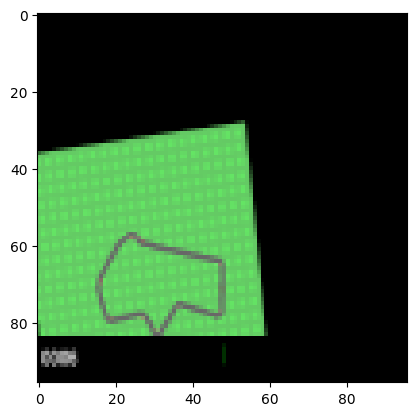

In [32]:
s, info = env.reset()
print(env.render())
_=plt.imshow(s)

In [33]:
#произведем шаг игры
a = env.action_space.sample()
print(a)

[-0.7462647   0.7693966   0.94810027]


Reward:  6.5889632107023415
Done?  False False


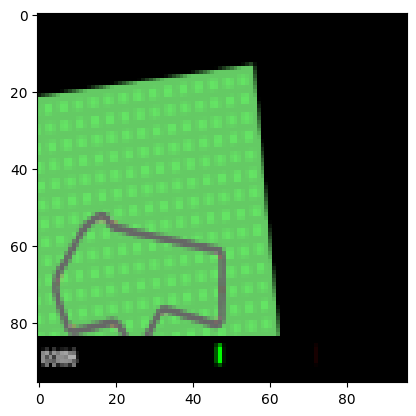

In [34]:
#возпроизведем это одно действие
s1, r, terminated, truncated, _ = env.step(a)
print('Reward: ', r)
print('Done? ', terminated, truncated)
_=plt.imshow(s1)

In [35]:
from gymnasium.wrappers import RecordVideo
import gymnasium as gym
import ale_py
from IPython.display import Video, display as ipy_display

# Регистрируем Atari
gym.register_envs(ale_py)

# Создаем среду (ВАЖНО: render_mode='rgb_array')
env = gym.make('CarRacing-v3', render_mode='rgb_array')

# Оборачиваем в RecordVideo (аналог Monitor)
env_sim = RecordVideo(
    env,
    video_folder=video_folder,  # папка для видео
    episode_trigger=lambda episode_id: True,  # записывать все эпизоды
    name_prefix='CarRacing_recording'
)

# Сброс среды - В Гимназиуме reset() возвращает (observation, info)
s, info = env_sim.reset()
totalReward = 0

for step in range(1000):
    # В Гимназиуме render() не всегда нужен - кадры захватываются автоматически
    # env_sim.render()  # МОЖНО УБРАТЬ, RecordVideo сам захватывает кадры

    # Случайное действие
    a = env_sim.action_space.sample()

    # Шаг среды - В Гимназиуме step() возвращает 5 значений!
    s, r, terminated, truncated, info = env_sim.step(a)

    # Объединяем флаги окончания
    done = terminated or truncated

    totalReward += r

    # Выводим ненулевые награды
    if r != 0:
        print(f'New reward = {r} (шаг {step})')

    # Проверка окончания эпизода
    if done:
        print(f'Эпизод закончен на шаге {step}')
        break

# Важно! Закрываем среду для сохранения видео
env_sim.close()

print(f'Total reward = {totalReward}')

# Проверяем, что видео сохранилось
import glob
videos = sorted(glob.glob(os.path.join(video_folder, '*.mp4')), key=os.path.getmtime)
if videos:
    latest_video = videos[-1]
    print(f"\nПоследнее видео: {latest_video}")
    print(f"Размер файла: {os.path.getsize(latest_video) / 1024:.1f} KB")
    # ИСПРАВЛЕНИЕ: используем ipy_display вместо display
    ipy_display(Video(latest_video, embed=True, width=600))

/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/ColabNotebooks/gym_videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


New reward = 7.094244604316547 (шаг 0)
New reward = -0.09999999999999964 (шаг 1)
New reward = -0.09999999999999964 (шаг 2)
New reward = -0.09999999999999964 (шаг 3)
New reward = -0.09999999999999964 (шаг 4)
New reward = -0.09999999999999964 (шаг 5)
New reward = -0.09999999999999964 (шаг 6)
New reward = -0.09999999999999964 (шаг 7)
New reward = -0.09999999999999964 (шаг 8)
New reward = -0.09999999999999964 (шаг 9)
New reward = -0.09999999999999964 (шаг 10)
New reward = -0.09999999999999964 (шаг 11)
New reward = -0.09999999999999964 (шаг 12)
New reward = -0.09999999999999964 (шаг 13)
New reward = -0.09999999999999964 (шаг 14)
New reward = -0.09999999999999964 (шаг 15)
New reward = -0.09999999999999964 (шаг 16)
New reward = -0.09999999999999964 (шаг 17)
New reward = -0.09999999999999964 (шаг 18)
New reward = -0.09999999999999964 (шаг 19)
New reward = -0.09999999999999964 (шаг 20)
New reward = -0.09999999999999964 (шаг 21)
New reward = -0.09999999999999964 (шаг 22)
New reward = 3.497122302

In [36]:
import time
show_video()

Показываем видео: /content/drive/MyDrive/ColabNotebooks/gym_videos/CarRacing_recording-episode-0.mp4
   Размер: 336.5 KB
   Создано: Wed Feb 25 14:30:42 2026
